# Data Analyst Job Market Analysis

## Project Objective

This project analyzes Data Analyst job postings to understand the current demand for skills, salaries, locations, seniority levels, remote opportunities, and entry-level positions.

### Key Questions

- What skills are most frequently requested in Data Analyst job postings?
- How does salary vary by skill and career level?
- Where are Data Analyst jobs concentrated?
- How common are remote opportunities?
- How large is the entry-level Data Analyst job market?
- What skills are most commonly requested in entry-level Data Analyst postings?

The goal is to use these findings to better understand the Data Analyst job market and identify skills and opportunities relevant to entry-level candidates.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
df = pd.read_csv("../data/gsearch_jobs.csv")

In [2]:
df["date_time"] = pd.to_datetime(df["date_time"])
df_da = df[df["title"].str.contains("Data Analyst", case=False, na=False)].copy()
df_da["description_tokens"] = df_da["description_tokens"].apply(ast.literal_eval)

## Dataset Overview

This analysis uses job posting data from Luke Barousse's Data Analyst job dataset.

After filtering the original dataset for job titles containing "Data Analyst," the analysis contains:

* **38,570 Data Analyst job postings**
* **Date range:** November 4, 2022 – April 18, 2025
* **5,974 postings** include standardized salary information
* **Median reported salary:** $83,440

### Data Limitations

Salary information is available for only **15.5%** of the Data Analyst postings. Therefore, salary findings are based only on postings with reported salary information and may not represent the entire job market.

The dataset ends on **April 18, 2025**, so 2025 represents a partial year and should not be compared directly with complete calendar years.


## Data Preparation

The original job posting dataset was prepared for analysis by:

1. changing the `date_time` column to a datetime format.
2. use filter to only include job title that include "Data Analyst"
3. Converting the `description_tokens` column from text representation into Python lists so that job skills could be analyzed.

# Analysis



## 1. Skills in Demand

### What are the most in-demand skills for Data Analyst jobs?

To identify the most in-demand skills, the `description_tokens` field was analyzed across all Data Analyst job postings.

The percentage represents the share of Data Analyst job postings that mentioned each skill. Because a single job posting can mention multiple skills, the percentages do not add up to 100%.

In [3]:
from collections import Counter

In [4]:
#cleaning steps

In [5]:
skill_counts = Counter(
    skill
    for skills in df_da["description_tokens"]
    for skill in skills
)

In [6]:
top_skills = pd.DataFrame(
    skill_counts.most_common(10),
    columns=["skill", "count"]
)

top_skills["percentage"] = top_skills["count"] / len(df_da) * 100

In [7]:
df_da["location"] = df_da["location"].str.strip()

In [8]:
df_da["year"] = df_da["date_time"].dt.year

In [9]:
df_da["month"] = df_da["date_time"].dt.month

In [10]:
df_da.to_csv("../data/data_analyst_cleaned.csv", index=False)

In [11]:
#What are the most in-demand skills for Data Analyst jobs?

In [12]:
top_skills = top_skills.sort_values("count", ascending=False)

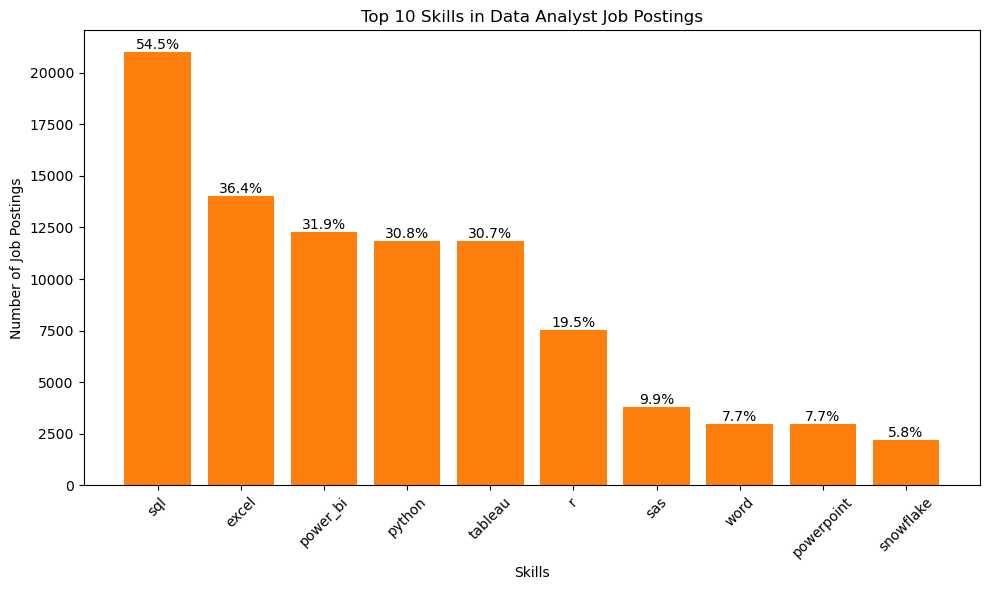

In [13]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    top_skills["skill"],
    top_skills["count"]
)
plt.bar(top_skills["skill"], top_skills["count"])
plt.title("Top 10 Skills in Data Analyst Job Postings")
plt.ylabel("Number of Job Postings")
plt.xlabel("Skills")
plt.xticks(rotation=45)
plt.tight_layout()

for bar, percentage in zip(bars, top_skills["percentage"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom"
    )

plt.savefig("../charts/top_10_data_analyst_skills.png", dpi=300, bbox_inches="tight")
plt.show()

#SQL is the most frequently requested skill, 
# appearing in 21,003 postings (54.45%),
#  followed by Excel, Power BI, Python, and Tableau.

### Key Finding

SQL is the most frequently requested skill in Data Analyst job postings, appearing in more than half of the postings. Excel, Power BI, Python, and Tableau are also among the most frequently requested skills.

This suggests that a strong entry-level Data Analyst skill set should include SQL and Excel, along with a visualization or programming tool such as Power BI, Tableau, or Python.

### Top Skills in Data Analyst Job Postings

The chart shows the ten skills most frequently mentioned in Data Analyst job postings. SQL has the highest demand, followed by Excel, Power BI, Python, and Tableau.

These results highlight the importance of combining data querying, spreadsheet analysis, visualization, and programming skills when preparing for a Data Analyst career.

# Does the required skill set change by year?
questin: Has the demand for skills changed from 2022 → 2025?
The focus is on SQL, Excel, Power BI, Python, and Tableau

In [14]:
sql_by_year = df_da.groupby(df_da["date_time"].dt.year)["description_tokens"].apply(
    lambda x: x.apply(lambda skills: "sql" in skills).mean() * 100
)

python_by_year = df_da.groupby(df_da["date_time"].dt.year)["description_tokens"].apply(
    lambda x: x.apply(lambda skills: "python" in skills).mean() * 100
)

In [15]:
skill_trends = pd.DataFrame({
    "sql": sql_by_year,
    "python": python_by_year
})

In [16]:
skills = ["sql", "excel", "power_bi", "python", "tableau"]

skill_trends = pd.DataFrame()

for skill in skills:
    skill_trends[skill] = (
        df_da.groupby("year")["description_tokens"]
        .apply(lambda x: x.apply(lambda skills: skill in skills).mean() * 100)
    )



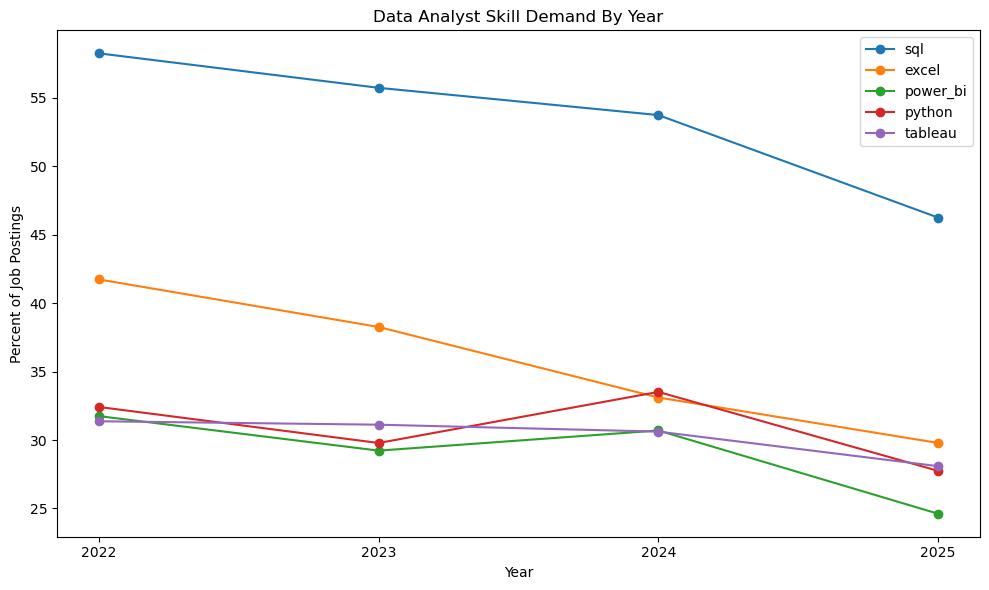

In [17]:
plt.figure(figsize=(10,6))

skills_to_plot = ["sql", "excel", "power_bi", "python", "tableau"]


for skill in skills_to_plot:
    plt.plot(
        skill_trends.index,
        skill_trends[skill],
        marker="o",
        label=skill
    )

plt.title("Data Analyst Skill Demand By Year")
plt.xlabel("Year")
plt.ylabel("Percent of Job Postings")
plt.xticks(skill_trends.index)
plt.legend()
plt.savefig("../charts/Data Analyst Skill Trends.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

### Skill Demand Over Time — Key Finding

SQL remained the most frequently requested skill across the years analyzed. Excel, Power BI, Python, and Tableau also remained important Data Analyst skills, although their relative demand changed over time.

This shows that SQL has remained a consistently important skill in the Data Analyst job market, while employers continue to value a combination of spreadsheet, business intelligence, and programming skills.

In [18]:
# #quistion: what is the Power BI vs Tableau Demand by Year?
skill_trends["power_bi_vs_tableau"] = (skill_trends["power_bi"]-skill_trends["tableau"])


### Power BI vs. Tableau Demand

Because Power BI and Tableau are two of the most common Data Analyst visualization tools, this analysis compares their demand over time.

The comparison helps identify whether employer demand for these two tools has changed across the years in the dataset.

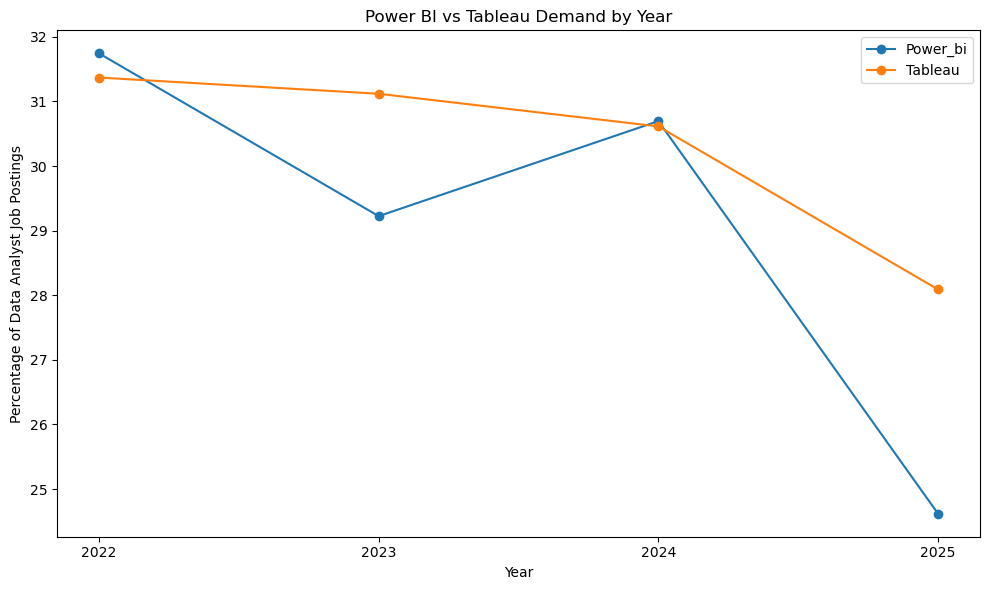

In [19]:
plt.figure(figsize=(10,6))

plt.plot(
    skill_trends.index,
    skill_trends["power_bi"],
    marker="o",
    label="Power_bi"
)

plt.plot(
    skill_trends.index,
    skill_trends["tableau"],
    marker="o",
    label="Tableau"
)

plt.title("Power BI vs Tableau Demand by Year")
plt.xlabel("Year")
plt.ylabel("Percentage of Data Analyst Job Postings")
plt.xticks(skill_trends.index)
plt.legend()

plt.tight_layout()



plt.savefig("../charts/Power BI vs Tableau Demand by Year.png", dpi=300, bbox_inches="tight")
plt.show()

### Power BI vs. Tableau — Key Finding

Power BI and Tableau showed relatively similar levels of demand across the years analyzed. Tableau remained slightly more consistent in 2025, while Power BI demand declined compared with earlier years.

Both tools remain valuable skills for Data Analysts, so learning either one can strengthen an entry-level Data Analyst skill set.

## 2. Salary Analysis

### Salary Distribution

The distribution of reported Data Analyst salaries is right-skewed, meaning that most reported salaries are concentrated in the lower-to-middle range, while a smaller number of high-paying postings extend the distribution upward.

The median reported salary is **$83,440**. However, salary information was available for only **5,974 of 38,570 postings**, so these results should be interpreted as the distribution of reported salaries rather than the entire Data Analyst job market.

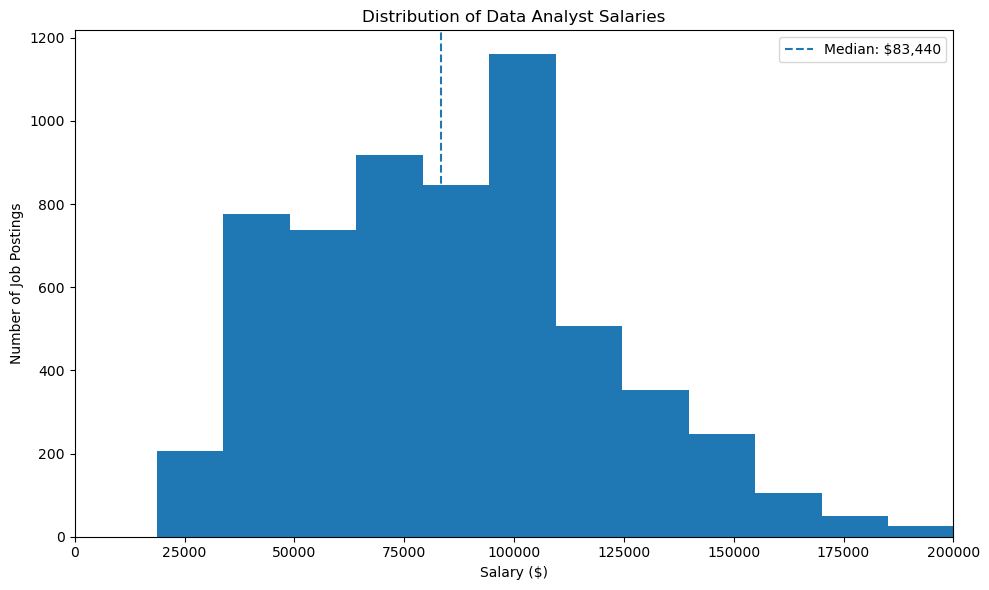

In [20]:

# What does the overall salary distribution look like for Data Analyst jobs? 

salary_data = df_da["salary_standardized"].dropna()

plt.figure(figsize=(10,6))
plt.hist(salary_data, bins=40)

plt.axvline(
    salary_data.median(),
    linestyle="--",
    label=f"Median: ${salary_data.median():,.0f}"
    )
plt.title("Distribution of Data Analyst Salaries")
plt.xlabel("Salary ($)")
plt.ylabel("Number of Job Postings")
plt.xlim(0, 200000)
plt.legend()

plt.tight_layout()
plt.savefig(
    "../charts/Distribution of Data Analyst Salaries.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Salary Distribution Key Finding
 Most of Data Analyst salary in dataset is between $83,000–$84,000, but a small number of  salaries increase above the average like $86,700.

### How does salary vary by Data Analyst career level?

This analysis compares the median reported salary across Data Analyst career levels to understand how compensation changes with increasing experience and responsibility.

In [21]:
df_da[["title", "company_name", "location", "salary_standardized"]].sort_values("salary_standardized", ascending=False).head(15)

,title,company_name,location,salary_standardized
22608,Freelance Data Analyst,Upwork,Anywhere,624000.0
34966,Cryptocurrency Market Data Analyst,Upwork,Anywhere,537680.0
15714,Experienced Looker BI Data Analyst Consultant ...,Upwork,Anywhere,364000.0
46243,Data Analyst for Ecommerce and Marketing Agency,Upwork,Anywhere,322400.0
45017,Data Analyst,Upwork,Anywhere,280800.0
45289,Market research data analyst - Contract to Hire,Upwork,Anywhere,260000.0
44740,Tableau prep/Data analyst expert,Upwork,Anywhere,260000.0
46452,Senior Data Analyst,Upwork,Anywhere,260000.0
46450,Amazon PPC Data Analyst,Upwork,Anywhere,260000.0
17244,Data Analyst,United States Parcel Service,"Adona, AR",240000.0


In [22]:
company_salary = df_da.groupby("company_name")["salary_standardized"].agg(["count","mean","median"]).sort_values("count", ascending=False).head(10)
#this show how Upwork offer most of the jobs but over all salarey median is lower the average median.

In [23]:
#Do Senior Data Analysts earn more than Data Analysts?

In [24]:
salary_by_title = (df_da.groupby("title")["salary_standardized"].agg(["count", "mean", "median"]).sort_values("count", ascending=False)).head(15)

In [25]:
salary_comparison = salary_by_title.loc[
    ["Data Analyst", "Data Analyst II", "Senior Data Analyst", "Lead Data Analyst"]
]

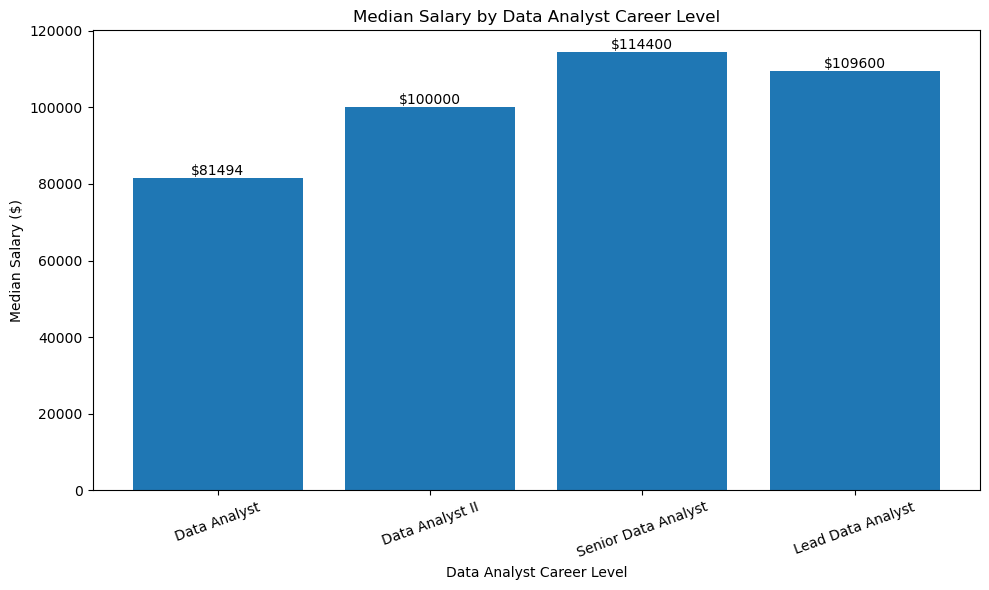

In [26]:
plt.figure(figsize=(10,6))
bars = plt.bar(
salary_comparison.index,
salary_comparison["median"]
)

plt.title("Median Salary by Data Analyst Career Level")
plt.xlabel("Data Analyst Career Level")
plt.ylabel("Median Salary ($)")
plt.xticks(rotation=20)


for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()


plt.savefig("../charts/Salary By Data Analyst Career.png", dpi=300, bbox_inches="tight")
plt.show()


### Salary by Career Level — Key Finding

Median reported salary generally increased with career level. Senior Data Analyst and Lead Data Analyst roles had substantially higher median salaries than general Data Analyst roles.

This suggests that career progression and greater responsibility are associated with higher reported salaries. However, this analysis shows an association and does not prove that career level alone causes higher pay.

In [27]:
#Which skills are associated with higher-paying Data Analyst jobs?

In [28]:
salary_by_skill = {}

for skill in skills:
    skill_jobs = df_da[
        df_da["description_tokens"].apply(lambda x: skill in x)
    ]

    median_salary = skill_jobs["salary_standardized"].median()

    salary_by_skill[skill] = median_salary



In [29]:
salary_by_skill_df = pd.DataFrame(
    list(salary_by_skill.items()),
    columns=["skill", "median_salary"]
)

salary_by_skill_df = salary_by_skill_df.sort_values(
    "median_salary",
    ascending=False
)

salary_by_skill_df

,skill,median_salary
0,sql,96500.0
4,tableau,96500.0
3,python,95000.0
2,power_bi,85280.0
1,excel,79500.0


### Which Data Analyst skills are associated with higher salaries?

This analysis compares the median reported salary of Data Analyst job postings that mention selected skills.

The goal is to identify which skills are associated with higher-paying Data Analyst positions.

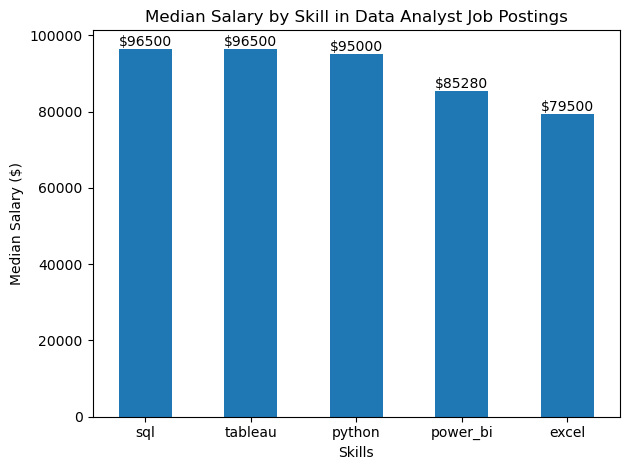

In [30]:
ax = salary_by_skill_df.plot(
    kind="bar",
    x="skill",
    y="median_salary",
    title="Median Salary by Skill in Data Analyst Job Postings",
    ylabel="Median Salary ($)",
    xlabel="Skills",
    legend=False
)
ax.bar_label(ax.containers[0], fmt="$%.0f")
plt.xticks(rotation=0)
plt.tight_layout()


plt.savefig("../charts/Salary by Skills.png", dpi=300, bbox_inches="tight")
plt.show()


### Salary by Slill_key finding
This chart clearly show that SQL and Tabluea is the most high paying skills at $(95500) followed by python at $(95000) then the Power_bi and Excel have lower median salary in this dataset. this means SQL Python and Tableau are valuable skill for targeting haigh pying jobs

In [31]:
company_salary = company_salary[company_salary["count"]>=10].sort_values("median", ascending=False)
company_salary.head(10)

,count,mean,median
company_name,,,
EDWARD JONES,98,122668.065306,144481.5
Harnham,63,132523.809524,135200.0
Insight Global,111,97866.084550,98800.0
Cox Communications,427,96233.840749,96500.0
Talentify.io,139,98445.817842,95000.0
City of Grand Junction,81,81494.400000,81494.4
Upwork,1491,78615.211268,68640.0
The Elite Job,73,52000.000000,52000.0
Saint Louis County Clerks Office,99,48570.626263,48391.2


# we can see that EDWARD JONES and Harnham companies are the lest count of job posting but with the heighest median salary. however the Upwork has the most job posting with the lowest median salary. it means a trad_off between job availability and salary level.

In [32]:
df_da["company_name_clean"] = (df_da["company_name"].str.strip().str.lower())

In [33]:
company_salary = (df_da.groupby("company_name_clean")["salary_standardized"].agg(["count","median"] ).query("count>=10").sort_values("median", ascending=False))
company_salary.head(15)

,count,median
company_name_clean,,
ey,11,148000.0000
harnham,63,135200.0000
storm3,10,130000.0000
motion recruitment,10,126870.0000
modis,11,124800.0000
edward jones,114,122470.5000
leadstack inc.,11,121680.0000
applicantz,22,119600.0000
net2source inc.,13,119600.0000


### Which companies offer higher reported salaries for Data Analyst roles?

This analysis compares the median reported salary among companies with Data Analyst job postings.

The comparison focuses on companies with reported salary information to identify organizations with higher median salaries in the dataset.

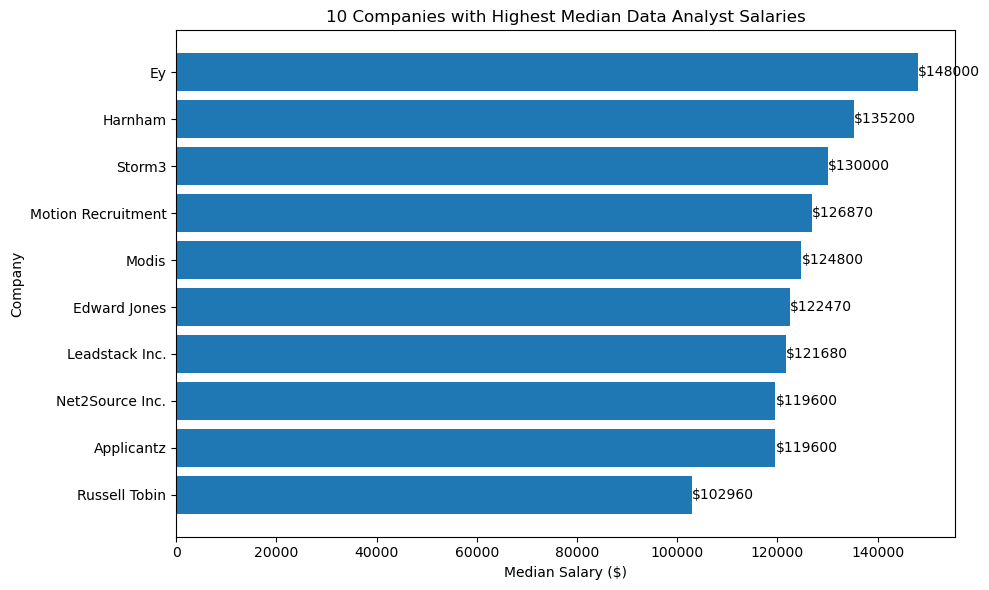

In [34]:
#Which companies offer the highest median salaries for Data Analyst positions?

top_companies = company_salary.head(10).sort_values("median")


plt.figure(figsize=(10,6))
bars = plt.barh(
    top_companies.index.str.title(),
    top_companies["median"]
)

plt.title("10 Companies with Highest Median Data Analyst Salaries")
plt.xlabel("Median Salary ($)")
plt.ylabel("Company")

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"${bar.get_width():.0f}",
        va="center",
        ha="left"
    )

plt.tight_layout()
plt.savefig("../charts/Top 10 Companies By Median Data Analyst Job.png", dpi=300, bbox_inches="tight")
plt.show()



### company Salary Median _ Key Finding

 between all the companies with reported salary data, EY had the highest median Data Analyst salary in this dataset. 

In [35]:
#where are most Data Analyst jobs are posted?
location_counts = df_da["location"].value_counts().head(15)



In [36]:
# The United States and Anywhere are not cities I want to separate them from the cities
city_locations = location_counts.drop(
    labels=["Anywhere", "United States"]
)


In [37]:
top_cities = city_locations.head(10)

## 3. Location Analysis

### Where are Data Analyst jobs concentrated?

This analysis examines the locations with the highest number of Data Analyst job postings.

Broad location categories such as "Anywhere" and "United States" are excluded so that the analysis focuses on specific cities.

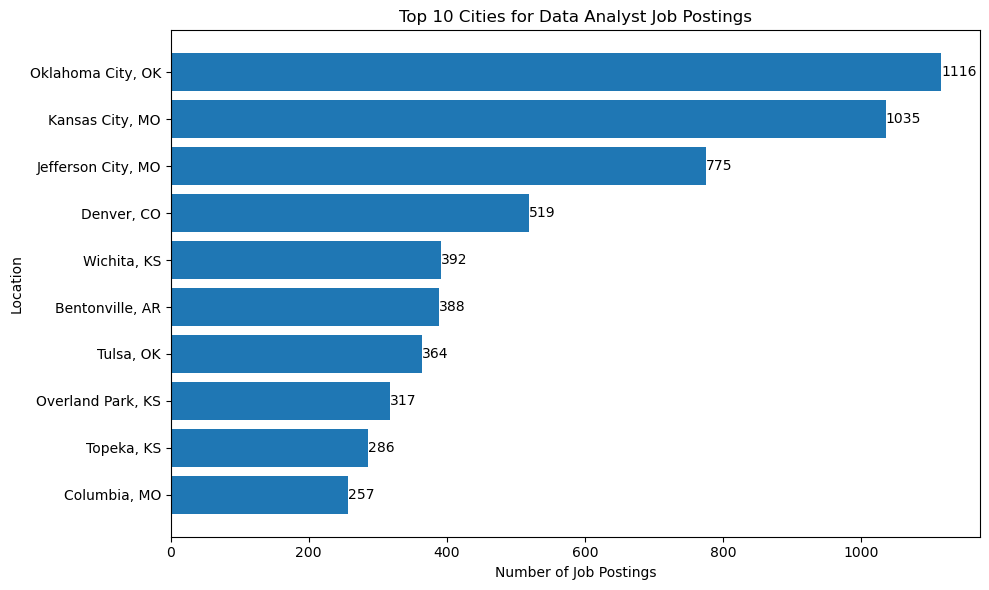

In [38]:
plt.figure(figsize=(10,6))
bars = plt.barh(
    top_cities.index[::-1],
    top_cities.values[::-1]
)
# I used [-1]to make showr the city with highest number of job postings appers first.

plt.title("Top 10 Cities for Data Analyst Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Location")

plt.bar_label(bars, fmt = "%.0f")

plt.tight_layout()
plt.savefig("../charts/Top 10 cities for Data Analyst Job.png", dpi=300, bbox_inches="tight")
plt.show()

# Note: "United States" and "Anywhere" are excluded because
# they are broad locations rather than specific cities.

### Top Data Analyst Job Location — Key Finding

Among city-specific Data Analyst job postings, **Oklahoma City had the highest number of postings with 1,116**, followed by **Kansas City and Jefferson City**.

The results show that Data Analyst job postings were concentrated in a relatively small number of cities within this dataset.


In [39]:
total_city_jobs = city_locations.sum()
total_city_jobs

np.int64(6096)

In [40]:
top_10_city_jobs = top_cities.sum()
top_10_city_jobs

np.int64(5449)

In [41]:
top_10_percentage = (top_10_city_jobs/total_city_jobs)*100


In [42]:
# 6,096 total city-specific postings
#5,449 postings came from the top 10 cities
#89.39% of city-specific postings were concentrated in those top 10 cities

### How concentrated are Data Analyst jobs across cities?

This analysis measures how much of the city-specific Data Analyst job market is represented by the top 10 cities.



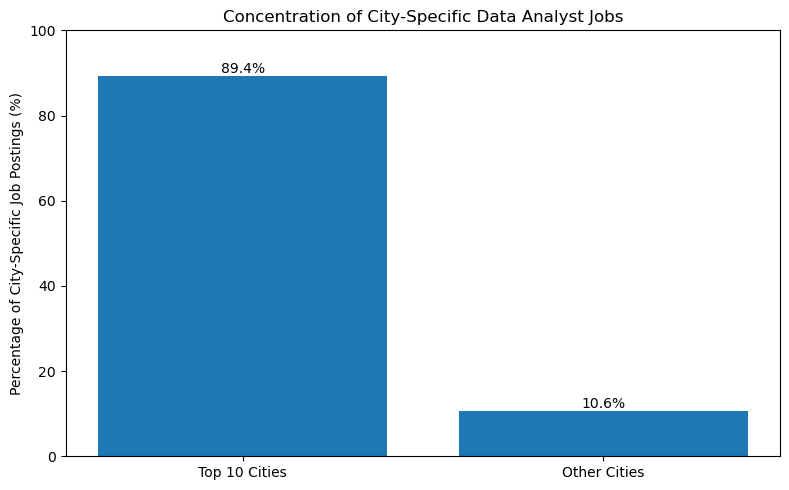

In [43]:
city_concentration = {
    "Top 10 Cities": top_10_percentage,
    "Other Cities": 100 - top_10_percentage
}

plt.figure(figsize=(8, 5))

bars = plt.bar(
    city_concentration.keys(),
    city_concentration.values()
)

plt.title("Concentration of City-Specific Data Analyst Jobs")
plt.ylabel("Percentage of City-Specific Job Postings (%)")

plt.bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in city_concentration.values()]
)

plt.ylim(0, 100)

plt.tight_layout()
plt.savefig("../charts/city_job_concentration.png", dpi=300, bbox_inches="tight")
plt.show()

# Note: "Anywhere" and "United States" are excluded because
# they are broad location labels rather than specific cities.


## City Concentration _ Key Finding
Among Data Analyst postings with a specific city listed, the top 10 cities account for 89.4% of city-specific postings.

In [44]:
#Remot VS non_remot jobs/Calculate remote percentage
df_da["work_from_home"].value_counts(dropna=False)
remote_percentage = (df_da["work_from_home"].eq(True).mean() * 100)
remote_percentage
## About 39% of Data Analyst postings in this dataset were explicitly identified as work-from-home.

np.float64(39.03292714544983)

In [45]:
remot_jobs = df_da["work_from_home"].value_counts()

### How common are remote Data Analyst jobs?

This analysis examines the share of Data Analyst job postings that explicitly indicate remote work.

Because missing values represent postings where remote status was not specified, they are treated as "unspecified" rather than non-remote.

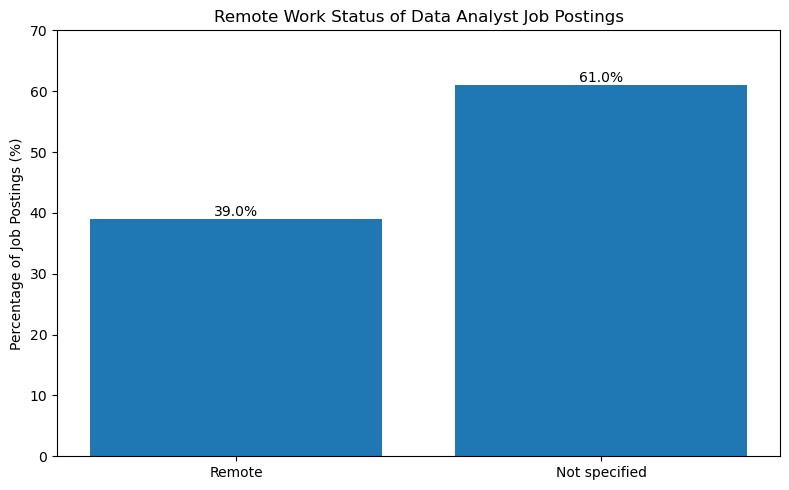

In [46]:
remote_counts = {
    "Remote": 15055,
    "Not specified": 23515
}

total = sum(remote_counts.values())

remote_percentages = {
    key: value / total * 100
    for key, value in remote_counts.items()
}

plt.figure(figsize=(8, 5))

bars = plt.bar(
    remote_percentages.keys(),
    remote_percentages.values()
)

plt.title("Remote Work Status of Data Analyst Job Postings")
plt.ylabel("Percentage of Job Postings (%)")

plt.bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in remote_percentages.values()]
)

plt.ylim(0, 70)


plt.tight_layout()

plt.savefig("../charts/Remote Work Status of Data Analyst Jobs.png", dpi=300, bbox_inches="tight")
plt.show()

## Remote Work _ Key Finding 
 This chart show that  39.0% of job posting in this dataset is remote and 61.0% did not specify whether the position was remote.

## 4. Seniority Analysis

### What seniority levels are most common in Data Analyst job postings?

This analysis examines the seniority levels assigned to Data Analyst job postings to understand how the market is distributed across different career levels.

Postings without a specified seniority level are classified as "Unspecified."

In [47]:

# Now focuse on typs of jobs. -what typs of Data Analyst job companies post. -what skills are they asking for.
df_da["title"].value_counts().head(15)

title
Data Analyst                              6444
Senior Data Analyst                       1748
Data Analyst II                            644
Business Data Analyst                      495
Lead Data Analyst                          428
Survey Data Analyst                        422
Data Analyst III                           284
Sr. Data Analyst, Marketing Operations     271
Sr. Data Analyst                           240
Financial Data Analyst                     227
Marketing Data Analyst                     223
Junior Data Analyst                        213
Data analyst                               163
Healthcare Data Analyst                    162
Data Analyst I                             159
Name: count, dtype: int64

In [48]:
df_da["title"].str.contains(
    "senior|sr\\.",
    case=False,
    na=False
).sum()

np.int64(6515)

In [49]:
df_da["title"].str.contains(
    "junior|entry|lead|principal|mid-level",
    case=False,
    na=False
).sum()

np.int64(2541)

In [50]:
seniority_keywords = {
    "Senior": "senior|sr\\.",
    "Junior/Entry": "junior|entry",
    "Lead": "lead",
    "Principal": "principal",
    "Mid-level": "mid-level"
}

for level, pattern in seniority_keywords.items():
    count = df_da["title"].str.contains(
        pattern,
        case=False,
        na=False
    ).sum()
    

    print(level, ":" , count)

Senior : 6515
Junior/Entry : 1001
Lead : 1101
Principal : 409
Mid-level : 31


In [51]:
df_da["seniority"] = "Other / Unspecified"
df_da.loc[
    df_da["title"].str.contains("principal", case=False, na=False),
    "seniority"
] = "Principal"

df_da.loc[
    df_da["title"].str.contains("lead", case=False, na=False),
    "seniority"
] = "Lead"

df_da.loc[
    df_da["title"].str.contains("senior|sr\\.", case=False, na=False),
    "seniority"
] = "Senior"


df_da.loc[
    df_da["title"].str.contains("mid_level", case=False, na=False),
    "seniority"
] = "Mid_level"

df_da.loc[
    df_da["title"].str.contains("junior|entry", case=False, na=False),
    "seniority"
] = "Junior / Entry"

df_da.loc[
    df_da["title"].str.contains(
        r"Data Analyst [IVX]+$|Data Analyst [123]", case=False, na=False),
    "seniority"
] = "Analyst I / II / III"

In [52]:
df_da["seniority"].value_counts()

seniority
Other / Unspecified     27726
Senior                   6443
Analyst I / II / III     2003
Lead                     1008
Junior / Entry           1001
Principal                 389
Name: count, dtype: int64

In [53]:
#calculate percentage
df_da["seniority"].value_counts(normalize=True)*100

seniority
Other / Unspecified     71.884885
Senior                  16.704693
Analyst I / II / III     5.193155
Lead                     2.613430
Junior / Entry           2.595281
Principal                1.008556
Name: proportion, dtype: float64

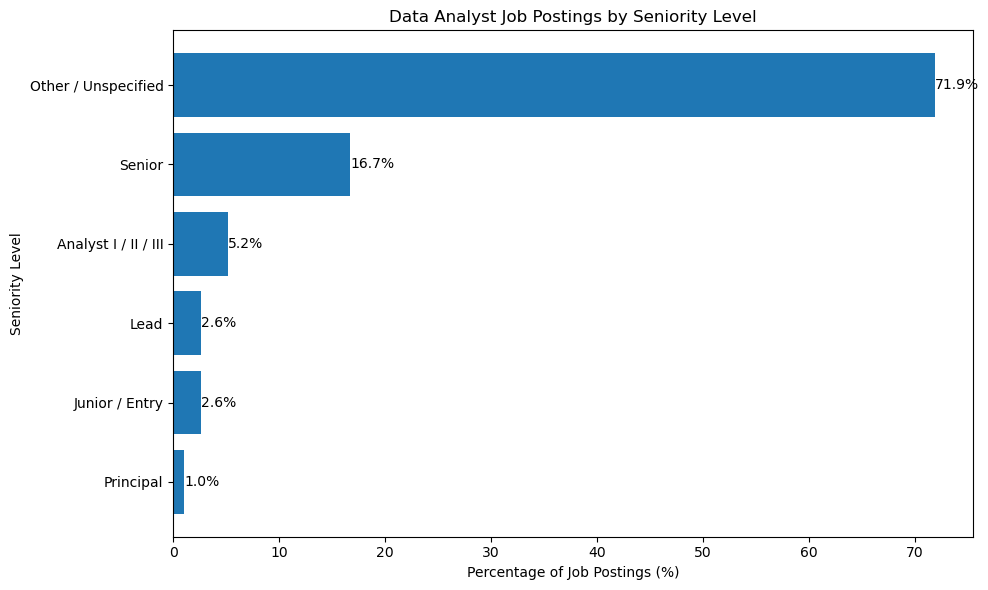

In [54]:
seniority_pct = (df_da["seniority"].value_counts(normalize=True).mul(100))


plt.figure(figsize=(10,6))

bars = plt.barh(
    seniority_pct.index[::-1],
    seniority_pct.values[::-1]
)

plt.title("Data Analyst Job Postings by Seniority Level")
plt.xlabel("Percentage of Job Postings (%)")
plt.ylabel("Seniority Level")
plt.bar_label(bars, fmt="%.1f%%")
plt.tight_layout()

plt.savefig(
    "../charts/data_analyst_seniority.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Seniority Analises _Key Finding 
This chart shows the distribution of Data Analyst job postings across different seniority levels. Most postings did not specify a seniority level, while explicitly identified senior-level positions accounted for 16.7% and junior/entry-level positions accounted for 2.6%.

## 5. Job Market Overview

### How has Data Analyst job posting volume changed over time?

In [55]:
monthly_jobs = df_da.groupby(df_da["date_time"].dt.to_period("M")).size()

In [56]:
monthly_summary = (
    df_da.groupby(df_da["date_time"].dt.to_period("M")).size().reset_index(name="job_count")
)

In [57]:
monthly_summary["year"] = monthly_summary["date_time"].dt.year

In [58]:
monthly_summary.groupby("year").agg(
    months=("date_time", "count"),
    total_jobs=("job_count", "sum"),
    average_monthly_jobs=("job_count", "mean")
)

,months,total_jobs,average_monthly_jobs
year,,,
2022,2,3736,1868.00
2023,12,20958,1746.50
2024,11,9757,887.00
2025,4,4119,1029.75


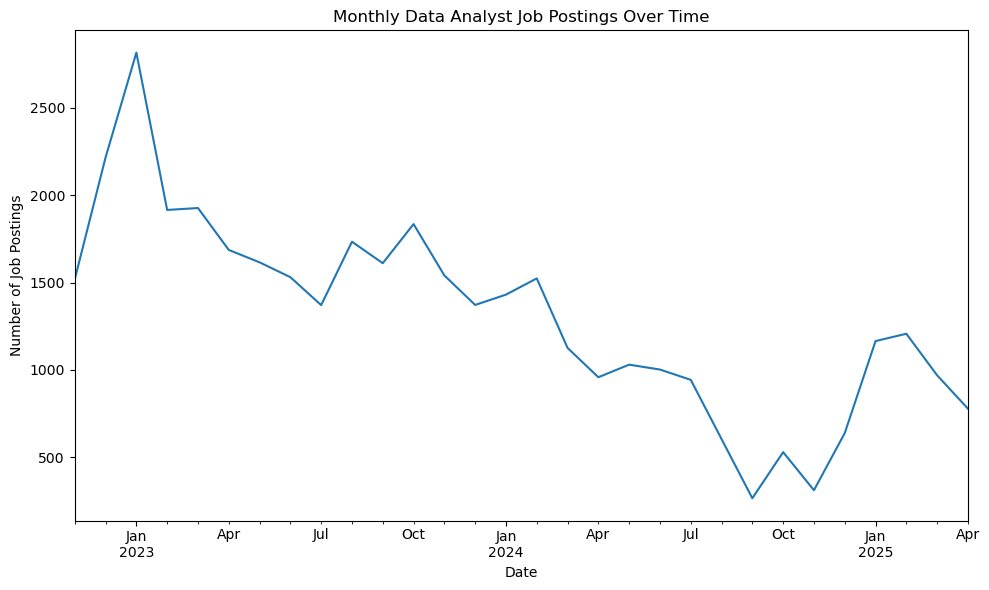

In [59]:
plt.figure(figsize=(10,6))

monthly_jobs.plot(
    kind="line",
    title="Monthly Data Analyst Job Postings Over Time",
    xlabel="Date",
    ylabel="Number of Job Postings"
)

plt.tight_layout()
plt.savefig("../charts/Data Analyst Job Posting Over Time.png", dpi=300, bbox_inches="tight")
plt.show()

### Job Posting Valume Over Time _ Key Finding 
This visualization shows a sharp increase in job postings at the beginning of 2023. The end of 2024 shows a decrease in the number of job postings, followed by 2025 which shows some recovery

### What are the most common Data Analyst job titles?

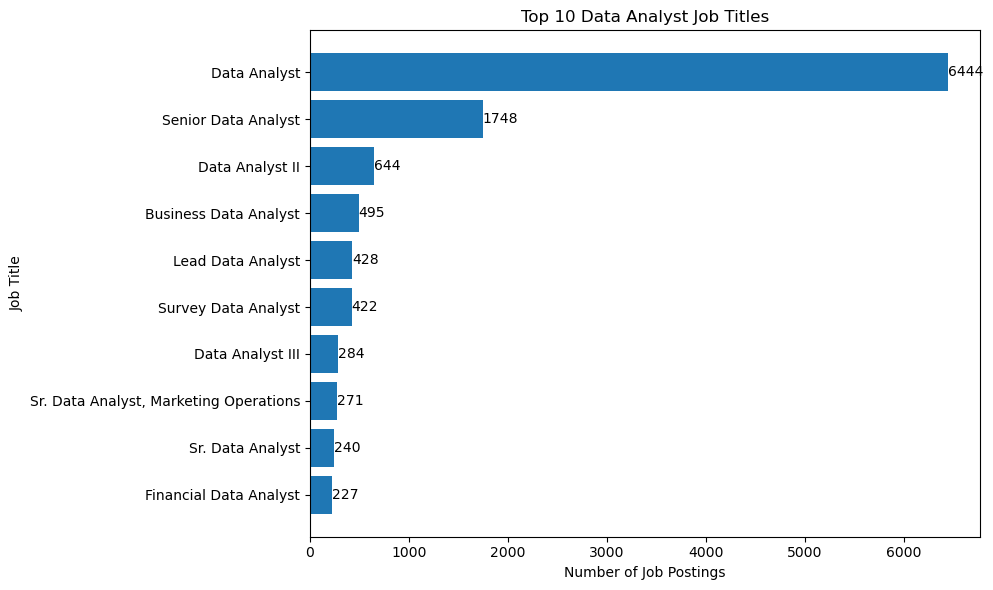

In [60]:
top_titles = df_da["title"].value_counts().head(10)
plt.figure(figsize=(10,6))
bars = plt.barh(
    top_titles.index[::-1],
    top_titles.values[::-1]
)
plt.title("Top 10 Data Analyst Job Titles")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Title")
plt.bar_label(bars, fmt="%.0f")
plt.tight_layout()
plt.savefig(
    "../charts/top_10_data_analyst_titles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Job Title — Key Finding

The chart shows that **Data Analyst** and **Senior Data Analyst** were the two most frequently posted job titles in the dataset.


# This chart show in more then half of Data Analyst jobs posting SQL is the number one required skill. Excel, Power bi, Python and Tableau are lists next in the line for requaired skills.

In [61]:
#entery level Data Analyst job Opportunities.
#What skills and opportunities are available to someone who wants to get in to Data Analytics?
#first i count the number of job explicitly marks as entery level/junior.


df_da["seniority"].value_counts()
#this shows that 1001 jobs are entery level. but not exactly since we have larg nomber of jobs unspecified.

seniority
Other / Unspecified     27726
Senior                   6443
Analyst I / II / III     2003
Lead                     1008
Junior / Entry           1001
Principal                 389
Name: count, dtype: int64

In [62]:
df_da[df_da["seniority"] == "Junior / Entry"]["title"].value_counts().head(20)

title
Junior Data Analyst                                                                                    213
Entry Level Data Analyst                                                                                62
Business Data Analyst (Junior)                                                                          35
Entry-Level Remote Data Analyst Job at Nike                                                             27
UT Dallas Data Analyst Entry Level Opportunity                                                          27
Entry-Level Remote Nike Data Analyst ($37/Hour) in  The Bronx, NY in Remote Job Team                    27
Home Depot Data Entry Jobs ||Remote|| (Senior Data Analyst) – MySmartPros                               21
Entry Level Data Analyst – CCS Global Tech – USA                                                        18
Junior Data Analyst, Excel Experience Required - Work From Home                                         17
Virtual Data Analyst / Entry le

In [63]:
junior_entry_pct = ((df_da["seniority"] == "Junior / Entry").sum()/len(df_da)*100)
junior_entry_pct

np.float64(2.5952813067150635)

# Only about 2.6% of the Data Analyst postings were explicitly labeled as Junior/Entry-level

In [64]:
#now I want to know if this number of entry level jobs are increasing or decreasing over time.
df_da[df_da["seniority"] == "Junior / Entry"].groupby(df_da["date_time"].dt.year
).size()

date_time
2022     82
2023    378
2024    238
2025    303
dtype: int64

In [65]:
#this result show that the number of jobs increase from 2022 to 2023 and drop in 2024 and recovery in 2025. 
#now I want to know what percentage of Data Analyst jobs avilable in the market is explicitly Junior/Entry?


yearly_entry = (df_da.groupby(df_da["date_time"].dt.year).apply(lambda x: (x["seniority"] == "Junior / Entry").sum()/len(df_da)*100))
yearly_entry

date_time
2022    0.212600
2023    0.980036
2024    0.617060
2025    0.785585
dtype: float64

## 6. Entry-Level Data Analyst Opportunities

### How many Data Analyst jobs are explicitly classified as entry-level?

This analysis focuses on Data Analyst job postings classified as "Junior / Entry" in the seniority field.

The goal is to understand the availability of explicitly entry-level opportunities and how their volume has changed over time.

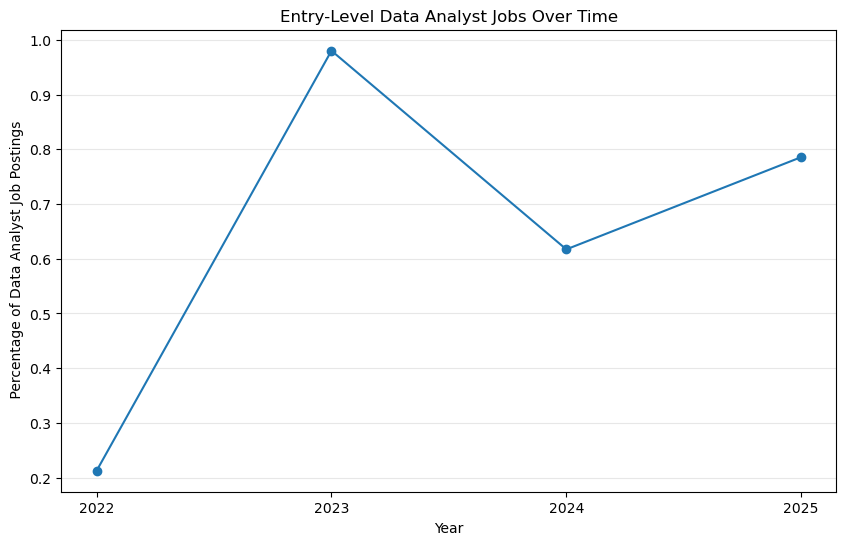

In [66]:
plt.figure(figsize=(10,6))

plt.plot(
    yearly_entry.index,
    yearly_entry.values,
    marker="o"
)

plt.title("Entry-Level Data Analyst Jobs Over Time")
plt.xlabel("Year")
plt.ylabel(" Percentage of Data Analyst Job Postings")

plt.xticks(yearly_entry.index)
plt.grid(axis="y", alpha=0.3)
plt.savefig("../charts/entry_level_jobs_over_time.png", dpi=300, bbox_inches="tight")

plt.show()

### Entry-Level Data Analyst — Key Finding

Entry-level Data Analyst postings represented a small share of the overall Data Analyst job market. The number of explicitly entry-level postings varied across the years analyzed, with **2023 having the highest number among the complete years**.

Overall, the results do not show a clear upward trend in the number of explicitly entry-level postings.


In [67]:
#if someone want to enter in Data Analyst market what skill should they learn?
#most common skills in Junior/Entry level jobs.


In [68]:
entry_jobs = df_da[df_da["seniority"] == "Junior / Entry"]
skill_count = entry_jobs["description_tokens"].explode().value_counts().head(10)
skill_percentage = (skill_count / len(entry_jobs) *100).round(1)
skill_percentage



description_tokens
excel          50.8
sql            45.3
tableau        43.5
power_bi       42.0
python         39.2
r              23.2
java           13.3
go              8.2
sas             7.7
spreadsheet     7.7
Name: count, dtype: float64

### What skills are most commonly requested for entry-level Data Analyst jobs?

This analysis examines the skills mentioned in job postings explicitly classified as Junior / Entry level.

The goal is to identify which technical skills are most frequently requested for candidates entering the Data Analyst field.

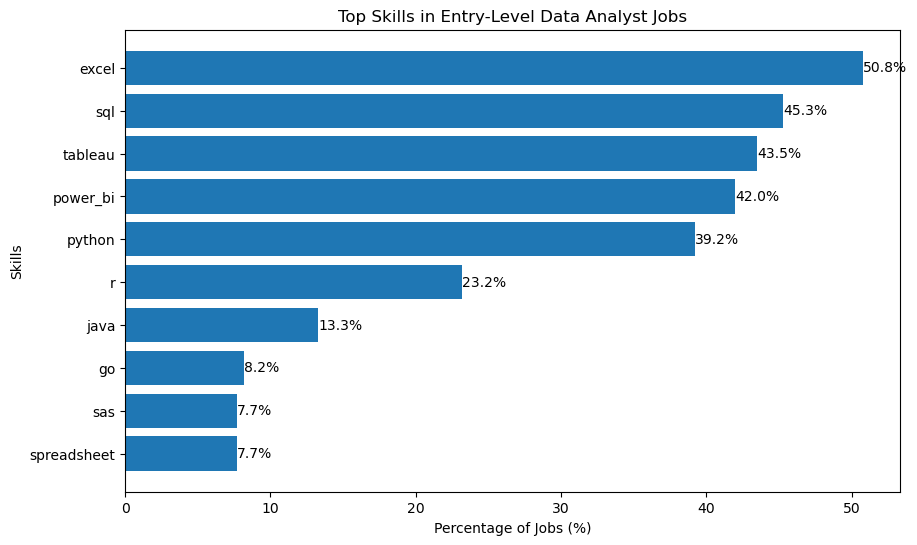

In [69]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    skill_percentage.index[::-1],
    skill_percentage.values[::-1]

)

plt.title("Top Skills in Entry-Level Data Analyst Jobs")
plt.xlabel("Percentage of Jobs (%)")
plt.ylabel("Skills")
plt.bar_label(bars, fmt="%.1f%%")

plt.savefig("../charts/entry_level_skills.png", dpi=300, bbox_inches="tight")

plt.show()

### Entry-Level Skills — Key Finding

Among explicitly entry-level Data Analyst postings, **Excel was the most frequently requested skill**, followed by **SQL, Tableau, and Power BI**. Python was also commonly mentioned.

These results show that spreadsheet, SQL, data visualization, and programming skills were frequently requested in entry-level Data Analyst job postings.


### What are the reported salaries for entry-level Data Analyst jobs?

This analysis examines reported salaries for Data Analyst postings explicitly classified as Junior / Entry level.

Because salary information is available for only a small portion of these postings, the results should be interpreted as reported salary information rather than a complete picture of entry-level compensation.

In [70]:
entry_salary = df_da[(df_da["seniority"] == "Junior / Entry" ) & 
(df_da["salary_standardized"].notna())
]["salary_standardized"]
entry_salary.describe()

count       131.000000
mean      61211.186870
std       21004.179136
min       24960.000000
25%       52000.000000
50%       52000.000000
75%       65510.000000
max      176800.000000
Name: salary_standardized, dtype: float64

In [71]:
#how dose entry level salary change over time?
entry_salary_by_year = df_da[(df_da["seniority"] == "Junior / Entry" ) & 
(df_da["salary_standardized"].notna())
].groupby(df_da["date_time"].dt.year)["salary_standardized"].agg(["count", "mean", "median"])
entry_salary_by_year

,count,mean,median
date_time,,,
2022,15,73975.725333,69680.0
2023,76,57021.778947,52000.0
2024,33,59865.890909,52000.0
2025,7,85685.714286,72800.0


### How common are remote opportunities for entry-level Data Analysts?

This analysis examines the remote work status of Data Analyst postings explicitly classified as Junior / Entry level.

The goal is to understand how many entry-level postings explicitly indicate remote work.

As with the overall remote analysis, missing values represent postings where remote status was not specified rather than postings that are confirmed to be non-remote.

In [72]:
entry_remote = df_da[
    df_da["seniority"] == "Junior / Entry"
    ]["work_from_home"].value_counts(dropna=False)
entry_remote
#this result show most of entry level Data Analyst jobs are entry_level.

work_from_home
True    613
NaN     388
Name: count, dtype: int64

In [73]:
#now I want to know is entry_level jobs are more likly to be remote then the over all jobs.

entry_remote_pct = (entry_remote[True] / len(entry_jobs) * 100)
entry_remote_pct

np.float64(61.23876123876124)

In [74]:
overall_remote_pct = (
    df_da["work_from_home"].eq(True).sum()/ len(df_da)* 100
)

round(overall_remote_pct, 1)

np.float64(39.0)

In [75]:
#entry_levl jobs market remote: 61%
#All Data Analyst jobs market remote: 39%.


### Entry-Level Remote Opportunities — Key Finding

Approximately **61.2% of explicitly entry-level Data Analyst postings indicated remote work**, compared with **39.0% of all Data Analyst postings**.

This suggests that remote opportunities were more common among explicitly entry-level postings in this dataset. However, some entry-level postings did not specify their remote status, so the results cannot determine how many of the remaining positions were on-site or hybrid.


In [76]:
entry_jobs["schedule_type"].value_counts(dropna=False)

schedule_type
Full-time                               730
Part-time                               103
Full-time and Part-time                  68
Contractor                               56
Contractor and Temp work                 23
Full-time and Contractor                  7
Full-time and Temp work                   6
Temp work                                 3
Internship                                2
NaN                                       2
Full-time, Contractor, and Temp work      1
Name: count, dtype: int64

In [77]:
# This result show out of all 1001 entry_level jobs posting 730 are full_time which is about 72.9%. 

# Entry_level Data Analyst jobs hold small postion in job market.
Excel and SQL are the most requested skill for entry_level.
Next Tableau, Power BI, Python are high demond skills.
Most entry_level jobs are full_time.d
A large share of job postings are marked as remote.

# 7. Conclusion

## Key Findings

This analysis examined Data Analyst job postings to understand job market trends, in-demand skills, salary patterns, location, remote work, seniority, and entry-level opportunities.

The main findings are:

* **SQL** was the most frequently requested skill, appearing in more than half of Data Analyst job postings.
* **Excel, Power BI, Python, and Tableau** were also among the most frequently requested skills.
* Data Analyst salaries varied substantially by career level, with higher-level positions generally showing higher median reported salaries.
* **SQL and Tableau** had the highest median reported salaries among the selected skills, although these results show association rather than causation.
* Approximately **39.0%** of all Data Analyst postings explicitly indicated remote work.
* Among explicitly entry-level postings, approximately **61.2%** indicated remote work.
* Only **2.6%** of all postings were explicitly classified as Junior / Entry level, although many postings had unspecified seniority.
* **Excel and SQL** were the most commonly requested skills in explicitly entry-level Data Analyst postings.
* Entry-level salary information was limited, with only **131 of 1,001** explicitly entry-level postings reporting salary.

## Overall Takeaway

The analysis shows that **SQL and Excel** were among the most commonly requested skills in explicitly entry-level Data Analyst postings, while **Tableau, Power BI, and Python** were also frequently requested.

The results also show that remote opportunities are an important part of the Data Analyst market represented in this dataset.

However, several limitations should be considered. Salary information was missing from most postings, remote status was frequently unspecified, seniority was unspecified for many jobs, and the dataset ends in April 2025. Therefore, the findings should be interpreted as patterns within this dataset rather than a complete representation of the current Data Analyst job market.
